In [1]:
from pathlib import Path
import yaml
import os

DATASET_PATH = Path("../02_datasets/DUT_Anti_UAV")

yaml_path = DATASET_PATH / "data.yaml"

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

config

{'path': 'D:/master/Master_Drone_Detection/02_datasets/DUT_Anti_UAV',
 'train': 'images/train',
 'val': 'images/val',
 'test': 'images/test',
 'names': {0: 'UAV'}}

In [2]:
from pathlib import Path

splits = ["train", "val", "test"]

for split in splits:
    image_dir = DATASET_PATH / "images" / split
    
    count = len(list(image_dir.glob("*")))
    
    print(f"{split}: {count} images")

train: 5200 images
val: 2600 images
test: 2200 images


In [4]:
label_root = DATASET_PATH / "labels"

for split in splits:
    label_dir = label_root / split
    
    count = len(list(label_dir.glob("*.txt")))
    
    print(f"{split}: {count} labels")

train: 5200 labels
val: 2600 labels
test: 2200 labels


In [5]:
total_instances = {}

for split in splits:
    label_dir = label_root / split
    
    instances = 0
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            lines = f.readlines()
            
        instances += len(lines)
    
    total_instances[split] = instances
    
    print(f"{split}: {instances} UAV instances")

train: 5243 UAV instances
val: 2621 UAV instances
test: 2245 UAV instances


In [6]:
import numpy as np
import matplotlib.pyplot as plt

bbox_sizes = []

for split in splits:
    label_dir = DATASET_PATH / "labels" / split
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            lines = f.readlines()
            
        for line in lines:
            values = line.strip().split()
            
            # YOLO format:
            # class x_center y_center width height
            
            w = float(values[3])
            h = float(values[4])
            
            area = w * h
            
            bbox_sizes.append(area)

bbox_sizes = np.array(bbox_sizes)

print("Total UAV objects:", len(bbox_sizes))
print("Minimum area:", bbox_sizes.min())
print("Maximum area:", bbox_sizes.max())
print("Mean area:", bbox_sizes.mean())
print("Median area:", np.median(bbox_sizes))

Total UAV objects: 10109
Minimum area: 0.0
Maximum area: 0.70198827348
Mean area: 0.012969611298350182
Median area: 0.000510209568


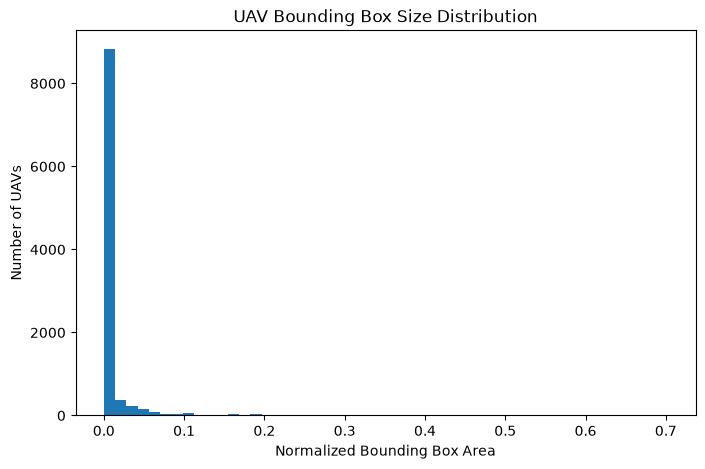

In [7]:
plt.figure(figsize=(8,5))

plt.hist(bbox_sizes, bins=50)

plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Number of UAVs")
plt.title("UAV Bounding Box Size Distribution")

plt.show()

In [8]:
tiny = np.sum(bbox_sizes < 0.001)
small = np.sum((bbox_sizes >= 0.001) & (bbox_sizes < 0.01))
medium = np.sum((bbox_sizes >= 0.01) & (bbox_sizes < 0.1))
large = np.sum(bbox_sizes >= 0.1)

total = len(bbox_sizes)

print(f"Tiny: {tiny} ({tiny/total*100:.2f}%)")
print(f"Small: {small} ({small/total*100:.2f}%)")
print(f"Medium: {medium} ({medium/total*100:.2f}%)")
print(f"Large: {large} ({large/total*100:.2f}%)")

Tiny: 6759 (66.86%)
Small: 1896 (18.76%)
Medium: 1103 (10.91%)
Large: 351 (3.47%)
